Analyse et Segmentation de Chansons Spotify
Techniques: Hierarchical Clustering, PCA, t-SNE, Decision Tree

In [1]:
!pip install -q scikit-learn matplotlib seaborn pandas numpy plotly


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Configuration graphiques
plt.style.use('dark_background')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor'] = '#16213e'

In [4]:
# URL du dataset spotify
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

In [5]:
print(f" Dataset chargé: {df.shape[0]} chansons, {df.shape[1]} colonnes")

 Dataset chargé: 32833 chansons, 23 colonnes


In [6]:
print(df.head())

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

In [7]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [8]:
print(f"\n Informations sur le dataset:")
print(df.info())


 Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       3283

In [9]:
print(f"\n Statistiques descriptives:")
print(df.describe())


 Statistiques descriptives:
       track_popularity  danceability        energy           key  \
count      32833.000000  32833.000000  32833.000000  32833.000000   
mean          42.477081      0.654850      0.698619      5.374471   
std           24.984074      0.145085      0.180910      3.611657   
min            0.000000      0.000000      0.000175      0.000000   
25%           24.000000      0.563000      0.581000      2.000000   
50%           45.000000      0.672000      0.721000      6.000000   
75%           62.000000      0.761000      0.840000      9.000000   
max          100.000000      0.983000      1.000000     11.000000   

           loudness          mode   speechiness  acousticness  \
count  32833.000000  32833.000000  32833.000000  32833.000000   
mean      -6.719499      0.565711      0.107068      0.175334   
std        2.988436      0.495671      0.101314      0.219633   
min      -46.448000      0.000000      0.000000      0.000000   
25%       -8.171000     

In [10]:

# Vérification des valeurs manquantes
print(f"\n Valeurs manquantes par colonne:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


 Valeurs manquantes par colonne:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


In [11]:

# suppression des lignes avec valeurs manquantes
df = df.dropna()
print(f"Dataset nettoyé: {df.shape[0]} ")

Dataset nettoyé: 32828 


Les features Spotify sont calculées par des algorithmes d'analyse audio:

1. DANCEABILITY (0-1): Mesure si une chanson est adaptée à la danse
    Combinaison: tempo, régularité du rythme, force du beat
   
2. ENERGY (0-1): Mesure l'intensité et l'activité perceptuelle
    Basé sur: dynamique, timbre, densité sonore
   
3. VALENCE (0-1): Mesure la positivité/négativité musicale
    1.0 = très joyeux, 0.0 = très triste/mélancolique
   
4. ACOUSTICNESS (0-1): Probabilité que la chanson soit acoustique
    Détecte l'absence d'amplification électronique
   
5. INSTRUMENTALNESS (0-1): Prédit l'absence de voix
    >0.5 = probablement instrumental
   
6. SPEECHINESS (0-1): Détecte la présence de mots parlés
    >0.66 = probablement du spoken word/podcast
   
7. LIVENESS (0-1): Probabilité de performance live
    Détecte la présence de public
   
8. TEMPO (BPM): Tempo moyen en battements par minute
   
9. LOUDNESS (dB): Volume global moyen
   
10. DURATION_MS: Durée en millisecondes

Ces features permettent de créer des profils musicaux uniques!

In [12]:
print(" EXPLORATORY DATA ANALYSIS ")

# Sélection des features audio importantes
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_ms']

 EXPLORATORY DATA ANALYSIS 


In [13]:

# Création du sous-dataset pour l'analyse
df_audio = df[audio_features + ['playlist_genre', 'track_popularity']].copy()

In [14]:
df_audio

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,track_popularity
0,0.748,0.916,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754,pop,66
1,0.726,0.815,-4.969,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600,pop,67
2,0.675,0.931,-3.432,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616,pop,70
3,0.718,0.930,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093,pop,60
4,0.650,0.833,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052,pop,69
...,...,...,...,...,...,...,...,...,...,...,...,...
32828,0.428,0.922,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375,edm,42
32829,0.522,0.786,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120,edm,20
32830,0.529,0.821,-4.899,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112,edm,14
32831,0.626,0.888,-3.361,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432,edm,15


EDM : pour dire electronic dance music égalment connu sous les termes dance music, club music


 Génération de la visualisation 1: Distribution des genres
 Calcul de la matrice de corrélation...
 Analyse de la relation Energy vs Danceability


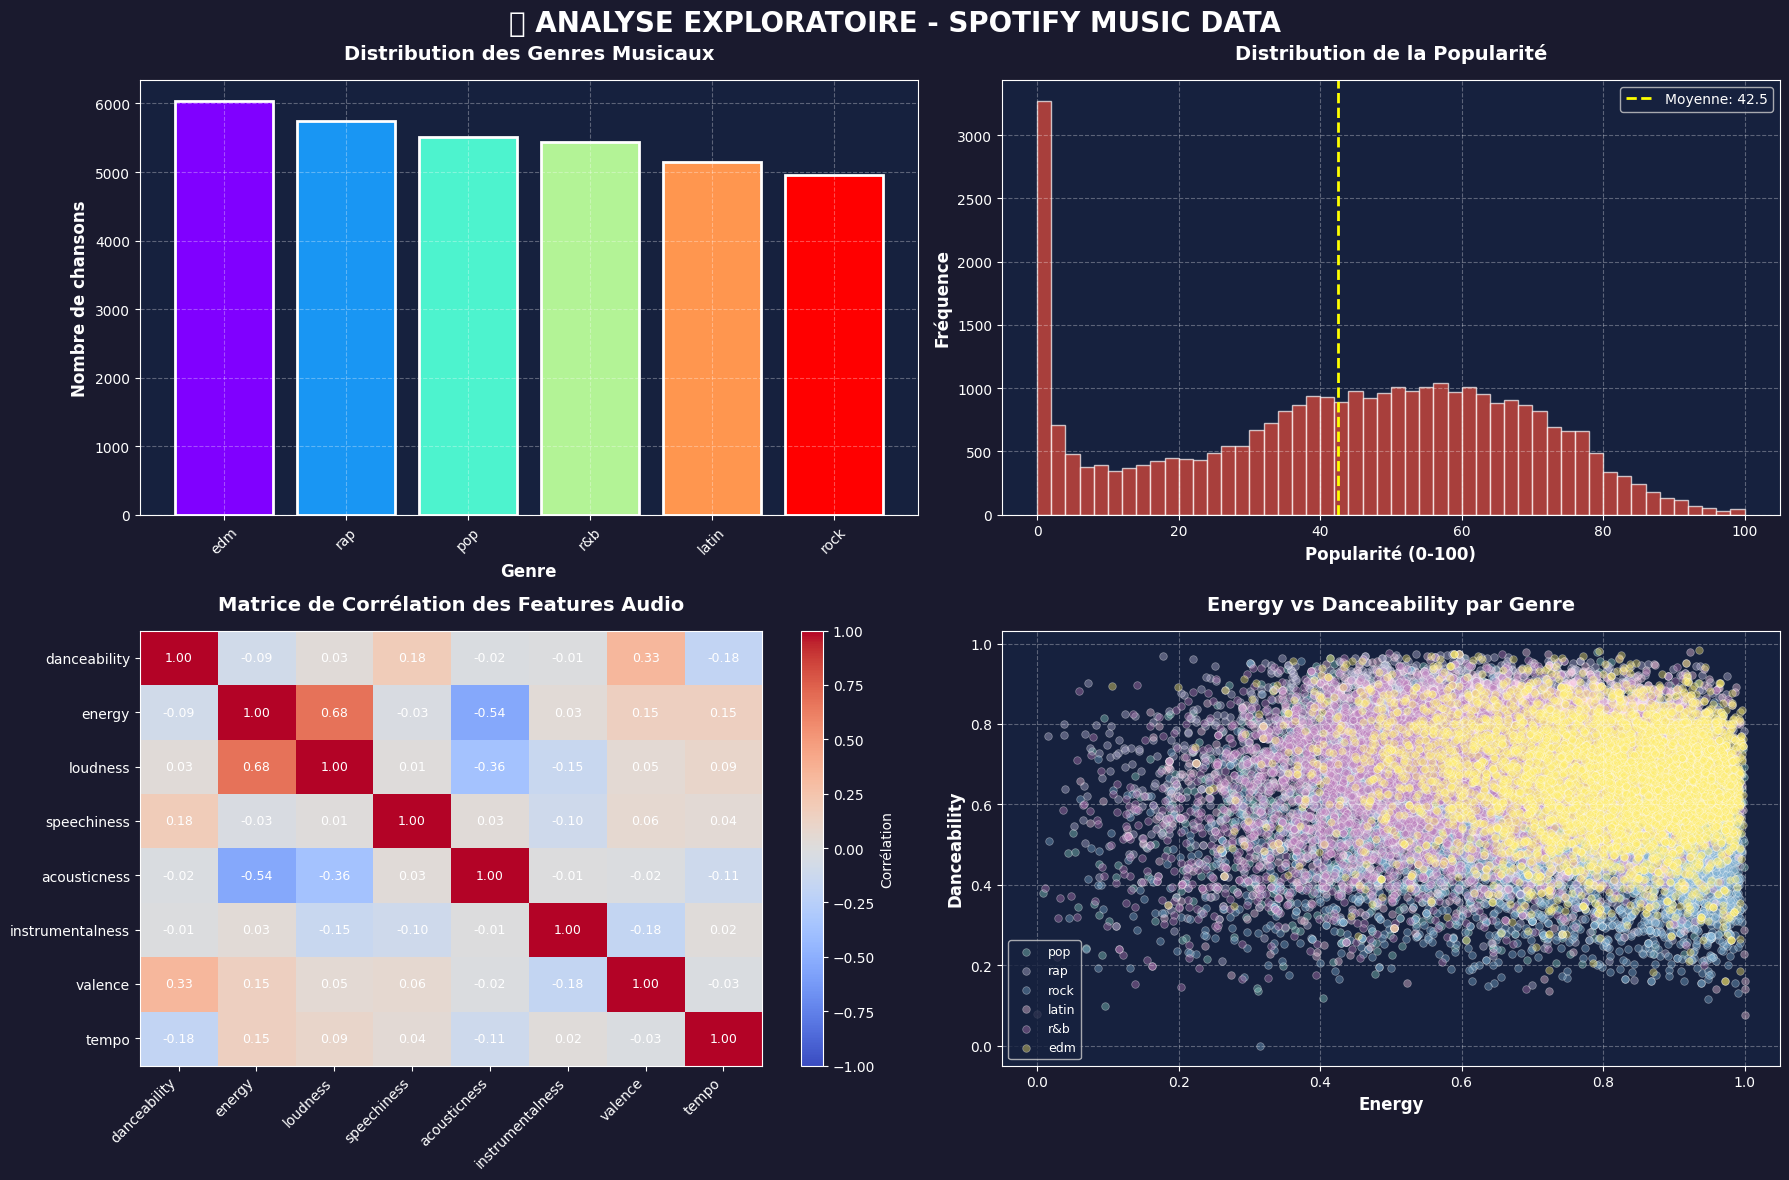

In [15]:






#  VISUALISATION 1: Distribution des genres musicaux
print("\n Génération de la visualisation 1: Distribution des genres")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('🎵 ANALYSE EXPLORATOIRE - SPOTIFY MUSIC DATA',
             fontsize=20, fontweight='bold', color='white', y=0.98)

# Genre distribution
genre_counts = df['playlist_genre'].value_counts()
colors_genre = plt.cm.rainbow(np.linspace(0, 1, len(genre_counts)))
axes[0,0].bar(genre_counts.index, genre_counts.values, color=colors_genre, edgecolor='white', linewidth=2)
axes[0,0].set_title('Distribution des Genres Musicaux', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Nombre de chansons', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(alpha=0.3, linestyle='--')

# Popularity distribution
axes[0,1].hist(df['track_popularity'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.7)
axes[0,1].set_title('Distribution de la Popularité', fontsize=14, fontweight='bold', pad=15)
axes[0,1].set_xlabel('Popularité (0-100)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Fréquence', fontsize=12, fontweight='bold')
axes[0,1].axvline(df['track_popularity'].mean(), color='yellow', linestyle='--',
                   linewidth=2, label=f'Moyenne: {df["track_popularity"].mean():.1f}')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3, linestyle='--')

# Correlation heatmap
print(" Calcul de la matrice de corrélation...")
audio_features_numeric = ['danceability', 'energy', 'loudness', 'speechiness',
                          'acousticness', 'instrumentalness', 'valence', 'tempo']
corr_matrix = df[audio_features_numeric].corr()

im = axes[1,0].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1,0].set_xticks(np.arange(len(audio_features_numeric)))
axes[1,0].set_yticks(np.arange(len(audio_features_numeric)))
axes[1,0].set_xticklabels(audio_features_numeric, rotation=45, ha='right')
axes[1,0].set_yticklabels(audio_features_numeric)
axes[1,0].set_title('Matrice de Corrélation des Features Audio',
                    fontsize=14, fontweight='bold', pad=15)

# Ajouter les valeurs de corrélation
for i in range(len(audio_features_numeric)):
    for j in range(len(audio_features_numeric)):
        text = axes[1,0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                             ha="center", va="center", color="white", fontsize=9)

plt.colorbar(im, ax=axes[1,0], label='Corrélation')

# Scatter: Energy vs Danceability par genre
print(" Analyse de la relation Energy vs Danceability")
genres_unique = df['playlist_genre'].unique()[:6]  # Top 6 genres
colors_scatter = plt.cm.Set3(np.linspace(0, 1, len(genres_unique)))

for idx, genre in enumerate(genres_unique):
    genre_data = df[df['playlist_genre'] == genre]
    axes[1,1].scatter(genre_data['energy'], genre_data['danceability'],
                     alpha=0.4, s=30, c=[colors_scatter[idx]],
                     label=genre, edgecolors='white', linewidth=0.5)

axes[1,1].set_title('Energy vs Danceability par Genre', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Energy', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Danceability', fontsize=12, fontweight='bold')
axes[1,1].legend(loc='best', fontsize=9)
axes[1,1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [16]:

# Trouver les corrélations fortes
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.4:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Corrélation': corr_matrix.iloc[i, j]
            })

if strong_corr:
    print("\n Corrélations fortes détectées (|r| > 0.4) :")
    for corr in sorted(strong_corr, key=lambda x: abs(x['Corrélation']), reverse=True):
        print(f"   • {corr['Feature 1']} ↔ {corr['Feature 2']}: {corr['Corrélation']:.3f}")


 Corrélations fortes détectées (|r| > 0.4) :
   • energy ↔ loudness: 0.677
   • energy ↔ acousticness: -0.540


In [17]:
print(" PRÉPARATION DES DONNÉES POUR LE CLUSTERING")


# Sélection des features pour le clustering (sans durée pour meilleure interprétation)
features_clustering = ['danceability', 'energy', 'valence', 'acousticness',
                       'instrumentalness', 'speechiness', 'tempo', 'loudness']

 PRÉPARATION DES DONNÉES POUR LE CLUSTERING


In [18]:
X = df[features_clustering].values
print(f" Features sélectionnées: {len(features_clustering)}")
print(f" Taille du dataset: {X.shape}")

 Features sélectionnées: 8
 Taille du dataset: (32828, 8)


POURQUOI NORMALISER ?

La normalisation est ESSENTIELLE car:

1. ÉCHELLES DIFFÉRENTES:
   - Tempo: 50-200 BPM (grande échelle)
   - Danceability: 0-1 (petite échelle)
   → Sans normalisation, le tempo dominerait le clustering!

2. DISTANCE EUCLIDIENNE:
   - Le clustering hiérarchique utilise des distances
   - Les features avec grandes valeurs auraient trop d'influence
   
3. STANDARDSCALER (choix):
   - Moyenne = 0, Écart-type = 1
   - Préserve la distribution
   - Gère bien les outliers modérés

In [19]:

# Normalisation avec StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f" Normalisation effectuée")
print(f" Moyenne après scaling: {X_scaled.mean():.6f}")
print(f" Écart-type après scaling: {X_scaled.std():.6f}")

 Normalisation effectuée
 Moyenne après scaling: 0.000000
 Écart-type après scaling: 1.000000


POURQUOI HIERARCHICAL CLUSTERING ?

1. DENDROGRAM VISUEL:
   - Montre la hiérarchie complète des regroupements
   - Permet de choisir le nombre optimal de cluster

2. WARD LINKAGE:
   - Minimise la variance intra-cluster
   - Crée des clusters compacts et équilibrés
   - Meilleur pour ce type de données continues

3. PAS DE K PRÉDÉFINI:
   - On peut décider après visualisation
   - Plus flexible que K-means

DÉTERMINATION DU NOMBRE OPTIMAL DE CLUSTERS:

Méthode d'analyse du dendrogram:
1. Observer les grandes "branches" (grandes distances verticales)
2. Tracer une ligne horizontale qui coupe le dendrogram
3. Le nombre de branches coupées = nombre de clusters

Pour ce dataset:
   - Ligne à distance sensiblement =15 coupe 5 branches
   - 5 clusters = bon équilibre complexité/interprétabilité
   - Correspond à sensiblement =5 "moods" musicaux distincts


 HIERARCHICAL CLUSTERING

 Création du dendrogram
 Application du clustering sur toutes les chansons
 5 clusters créés
 Silhouette Score: 0.110 (>0.5 = bon)

 Répartition des chansons:
   Cluster 0: 13,049 chansons (39.7%)
   Cluster 1: 7,198 chansons (21.9%)
   Cluster 2: 1,796 chansons (5.5%)
   Cluster 3: 7,165 chansons (21.8%)
   Cluster 4: 3,620 chansons (11.0%)


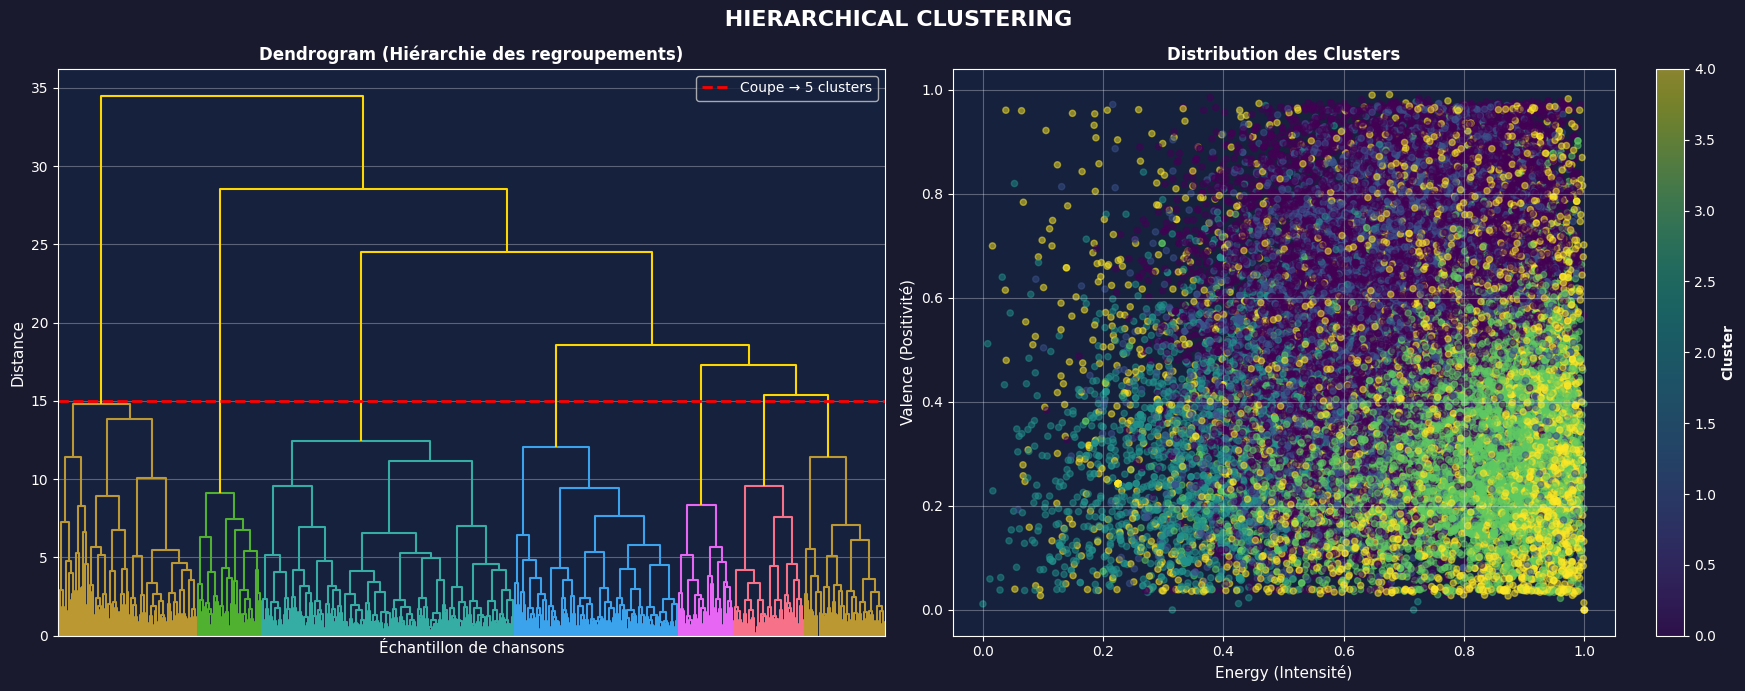

In [20]:

print("\n HIERARCHICAL CLUSTERING")

print("\n Création du dendrogram")

# On prend un échantillon pour que le graphique soit lisible
sample_size = 500
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Calcul de la hiérarchie
linkage_matrix = linkage(X_sample, method='ward')

#  Appliquer le clustering sur les données
print(" Application du clustering sur toutes les chansons")

n_clusters = 5  # Choisi d'après le dendrogram
hier_cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df['cluster'] = hier_cluster.fit_predict(X_scaled)

# Évaluation de la qualité
silhouette_avg = silhouette_score(X_scaled, df['cluster'])
print(f" {n_clusters} clusters créés")
print(f" Silhouette Score: {silhouette_avg:.3f} (>0.5 = bon)")

# Distribution
print(f"\n Répartition des chansons:")
for cluster_id in range(n_clusters):
    count = len(df[df['cluster'] == cluster_id])
    print(f"   Cluster {cluster_id}: {count:,} chansons ({count/len(df)*100:.1f}%)")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle(' HIERARCHICAL CLUSTERING',
             fontsize=16, fontweight='bold', color='white', y=0.98)

# Graphique 1: Dendrogram
dendrogram(linkage_matrix, ax=axes[0],
           color_threshold=15,
           above_threshold_color='#FFD700',
           no_labels=True)
axes[0].set_title('Dendrogram (Hiérarchie des regroupements)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Échantillon de chansons', fontsize=11)
axes[0].set_ylabel('Distance', fontsize=11)
axes[0].axhline(y=15, color='red', linestyle='--', linewidth=2,
                label=f'Coupe → {n_clusters} clusters')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Graphique 2: Clusters visualisés
scatter = axes[1].scatter(df['energy'], df['valence'],
                         c=df['cluster'],
                         cmap='viridis',
                         alpha=0.5,
                         s=20)
axes[1].set_title('Distribution des Clusters', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Energy (Intensité)', fontsize=11)
axes[1].set_ylabel('Valence (Positivité)', fontsize=11)
axes[1].grid(alpha=0.3)

# Légende colorée
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Cluster', fontsize=10, fontweight='bold')

plt.tight_layout()

plt.show()



In [21]:



# Analyse des caractéristiques de chaque cluster
print(" PROFIL MUSICAL DE CHAQUE CLUSTER")

cluster_profiles = df.groupby('cluster')[features_clustering].mean()

for cluster_id in range(n_clusters):
    print(f"\n CLUSTER {cluster_id}:")
    profile = cluster_profiles.loc[cluster_id]

    # Identifier les caractéristiques dominantes
    dominant = profile.nlargest(3)
    print(f"   Caractéristiques dominantes:")
    for feat, val in dominant.items():
        print(f"      • {feat}: {val:.2f}")

    # Interprétation musicale
    if profile['energy'] > 0.6 and profile['danceability'] > 0.6:
        mood = " ÉNERGIQUE & DANSANT (Ex: EDM, Pop)"
    elif profile['acousticness'] > 0.5:
        mood = " ACOUSTIQUE & CALME (Ex: Folk, Acoustic)"
    elif profile['valence'] > 0.6:
        mood = " JOYEUX & POSITIF (Ex: Happy Pop)"
    elif profile['instrumentalness'] > 0.5:
        mood = " INSTRUMENTAL (Ex: Classical, Ambient)"
    else:
        mood = " VARIÉ & ÉQUILIBRÉ"

    print(f"   Mood suggéré: {mood}")

 PROFIL MUSICAL DE CHAQUE CLUSTER

 CLUSTER 0:
   Caractéristiques dominantes:
      • tempo: 114.47
      • danceability: 0.72
      • energy: 0.69
   Mood suggéré:  ÉNERGIQUE & DANSANT (Ex: EDM, Pop)

 CLUSTER 1:
   Caractéristiques dominantes:
      • tempo: 128.11
      • danceability: 0.70
      • energy: 0.69
   Mood suggéré:  ÉNERGIQUE & DANSANT (Ex: EDM, Pop)

 CLUSTER 2:
   Caractéristiques dominantes:
      • tempo: 108.23
      • acousticness: 0.62
      • danceability: 0.52
   Mood suggéré:  ACOUSTIQUE & CALME (Ex: Folk, Acoustic)

 CLUSTER 3:
   Caractéristiques dominantes:
      • tempo: 127.36
      • energy: 0.79
      • danceability: 0.53
   Mood suggéré:  VARIÉ & ÉQUILIBRÉ

 CLUSTER 4:
   Caractéristiques dominantes:
      • tempo: 123.08
      • energy: 0.73
      • instrumentalness: 0.68
   Mood suggéré:  ÉNERGIQUE & DANSANT (Ex: EDM, Pop)


POURQUOI UTILISER PCA ?

PCA = Principal Component Analysis (Analyse en Composantes Principales)

OBJECTIF:
   Réduire 8 dimensions en 2 dimensions
   Tout en conservant le maximum d'information

COMMENT ÇA MARCHE ?
   1. Trouve les directions de variance maximale dans les données
   2. PC1 = direction avec le + de variance
   3. PC2 = direction perpendiculaire avec le + de variance restante
   
AVANTAGES:
    Visualisation 2D de données multi-dimensionnelles
    Conserve les relations entre points
    Linéaire = rapide et interprétable
   
LIMITATIONS:
    Suppose relations linéaires (d'où t-SNE après!)
    Peut perdre patterns non-linéaires

VARIANCE EXPLIQUÉE:
   Important! Indique combien d'info est conservée
   >70% = bon, >80% = excellent


\ Application de PCA (8D en 2D)
 Variance expliquée par PC1: 26.52%
 Variance expliquée par PC2: 18.70%
 Variance TOTALE expliquée: 45.22%
   → Attention: <50% - informations perdues significatives

 Contribution des features aux composantes principales:
                    PC1    PC2
danceability     -0.019  0.617
energy            0.619 -0.047
valence           0.118  0.570
acousticness     -0.499  0.049
instrumentalness -0.067 -0.315
speechiness      -0.007  0.349
tempo             0.179 -0.258
loudness          0.563  0.046


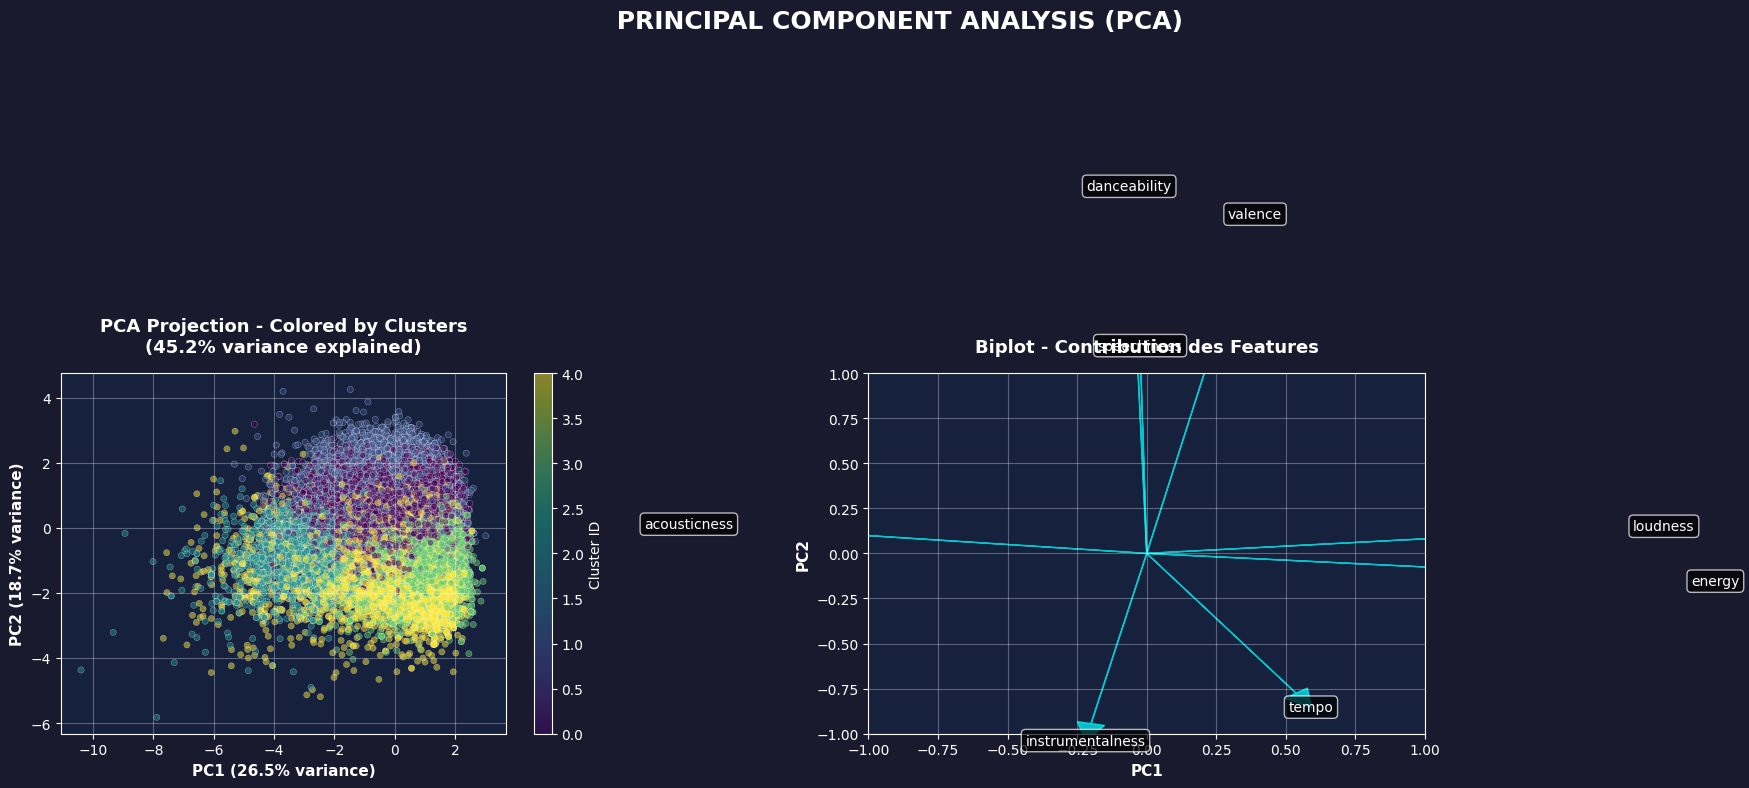

In [22]:

# Application du PCA
print(f"\ Application de PCA (8D en 2D)")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Analyse de la variance expliquée
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

print(f" Variance expliquée par PC1: {var_ratio[0]*100:.2f}%")
print(f" Variance expliquée par PC2: {var_ratio[1]*100:.2f}%")
print(f" Variance TOTALE expliquée: {cum_var[1]*100:.2f}%")

if cum_var[1] > 0.7:
    print(f"   → Excellent! >70% de l'information préservée")
elif cum_var[1] > 0.5:
    print(f"   → Bon! >50% de l'information préservée")
else:
    print(f"   → Attention: <50% - informations perdues significatives")

# Contributions des features originales
print(f"\n Contribution des features aux composantes principales:")
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_clustering
)
print(components_df.round(3))

# Visualisation PCA
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle(' PRINCIPAL COMPONENT ANALYSIS (PCA)',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# PCA scatter avec clusters
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'],
                         cmap='viridis', alpha=0.5, s=20,
                         edgecolors='white', linewidth=0.3)
axes[0].set_title(f'PCA Projection - Colored by Clusters\n({cum_var[1]*100:.1f}% variance explained)',
                 fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% variance)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% variance)',
                  fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Biplot - Contribution des features
for i, feature in enumerate(features_clustering):
    axes[1].arrow(0, 0, components_df.iloc[i, 0]*3, components_df.iloc[i, 1]*3,
                 head_width=0.1, head_length=0.1, fc='cyan', ec='cyan', alpha=0.7)
    axes[1].text(components_df.iloc[i, 0]*3.3, components_df.iloc[i, 1]*3.3,
                feature, fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

axes[1].set_title('Biplot - Contribution des Features',
                 fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('PC1', fontsize=11, fontweight='bold')
axes[1].set_ylabel('PC2', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()



POURQUOI t-SNE APRÈS PCA ?"
t-SNE = t-Distributed Stochastic Neighbor Embedding

DIFFÉRENCE CRUCIALE AVEC PCA:
   PCA → Relations LINÉAIRES
   t-SNE → Relations NON-LINÉAIRES (+ complexes)

COMMENT ÇA MARCHE ?
   1. Calcule similarités entre points dans l'espace original (8D)
   2. Crée une projection 2D qui préserve ces similarités
   3. Utilise optimisation itérative (d'où c'est plus lent)

AVANTAGES:
    Révèle structures cachées complexes
    Meilleure séparation visuelle des clusters
    Parfait pour visualisation finale

INCONVÉNIENTS:
    Plus lent que PCA (surtout avec beaucoup de données)
    Non-déterministe (résultats varient légèrement)
    Distances entre clusters moins interprétables

PARAMÈTRES CLÉS:
    perplexity=30: Balance focus local/global
    n_iter=1000: Nombre d'itérations d'optimisation
   
C'est pourquoi on fait PCA D'ABORD (vue globale)
puis t-SNE (vue détaillée)


 Application de t-SNE sur échantillon de 3000 chansons
   (t-SNE est computationnellement intensif)


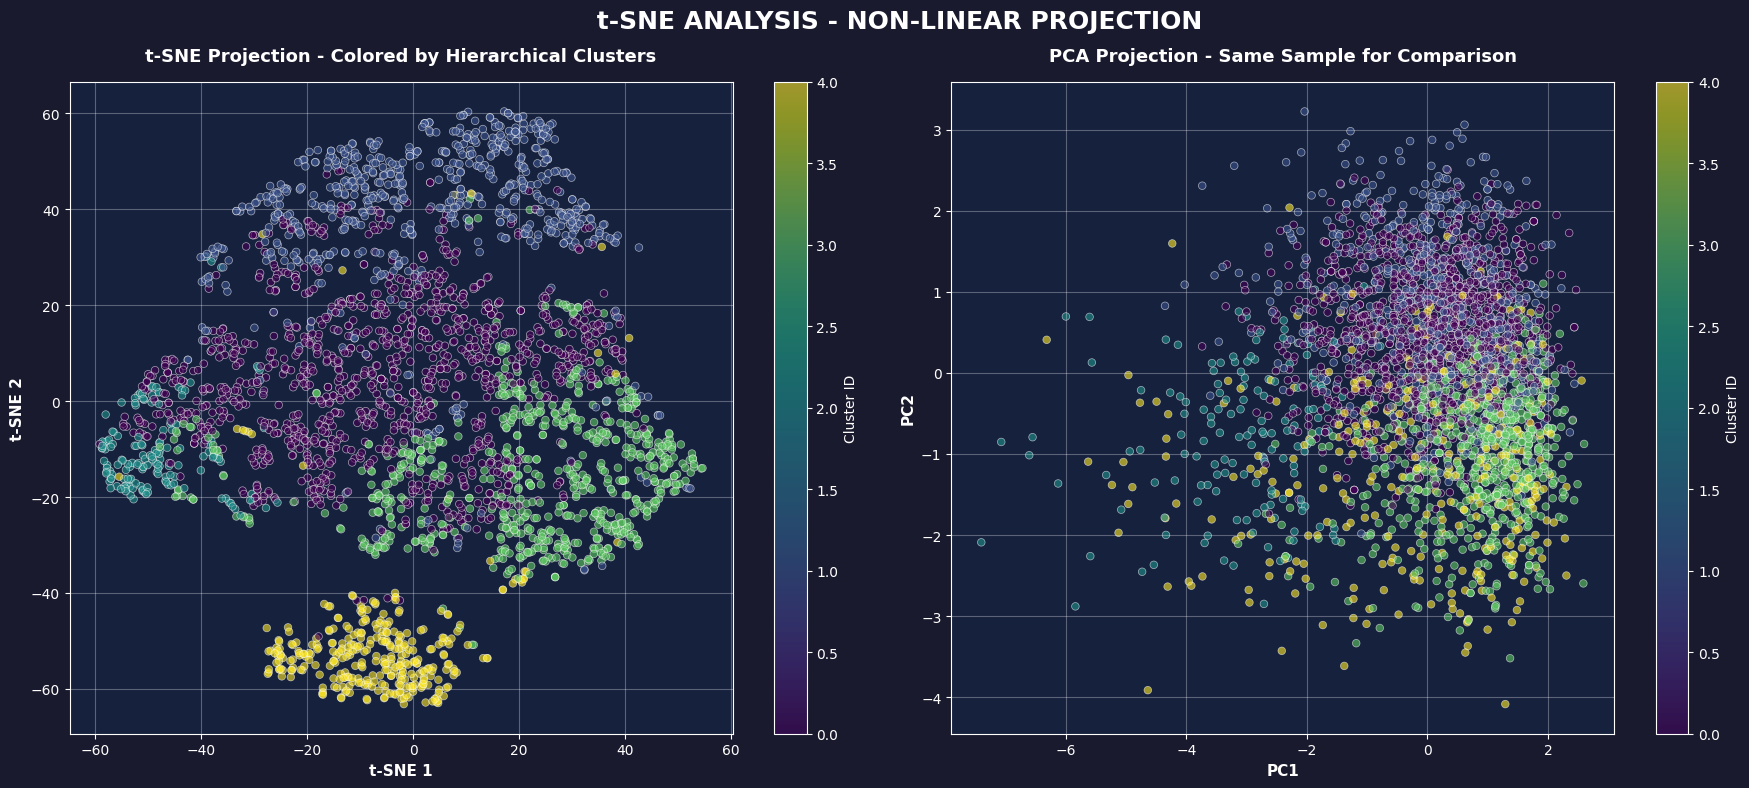

In [23]:


# Application t-SNE sur échantillon (pour performance)
sample_size_tsne = 3000  # le choix de 3000 est aléatoire pour voir les performances et avoir une meilleure visualisation
print(f"\n Application de t-SNE sur échantillon de {sample_size_tsne} chansons")
print("   (t-SNE est computationnellement intensif)")

np.random.seed(42)
sample_indices_tsne = np.random.choice(len(X_scaled), sample_size_tsne, replace=False)
X_sample_tsne = X_scaled[sample_indices_tsne]
clusters_sample = df['cluster'].iloc[sample_indices_tsne].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_sample_tsne)


# Visualisation t-SNE
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle(' t-SNE ANALYSIS - NON-LINEAR PROJECTION',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# t-SNE avec clusters
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_sample,
                          cmap='viridis', alpha=0.6, s=30,
                          edgecolors='white', linewidth=0.5)
axes[0].set_title('t-SNE Projection - Colored by Hierarchical Clusters',
                 fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('t-SNE 1', fontsize=11, fontweight='bold')
axes[0].set_ylabel('t-SNE 2', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Comparaison: PCA vs t-SNE pour même échantillon
X_pca_sample = pca.transform(X_sample_tsne)
scatter2 = axes[1].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                          c=clusters_sample, cmap='viridis', alpha=0.6, s=30,
                          edgecolors='white', linewidth=0.5)
axes[1].set_title('PCA Projection - Same Sample for Comparison',
                 fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('PC1', fontsize=11, fontweight='bold')
axes[1].set_ylabel('PC2', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')

plt.tight_layout()
plt.show()



COMPARAISON PCA vs t-SNE:

Observations attendues:
   PCA: Clusters plus "mélangés" mais distances globales préservées
   t-SNE: Clusters mieux sepqrés, structures locales révélées
   
- t-SNE montre que nos 5 clusters sont bien distincts
- Confirme la qualité de notre clustering hiérarchique

OBJECTIF DU DECISION TREE DANS CE PROJET:

PROBLÈME À RÉSOUDRE:
   Prédire si une chanson sera POPULAIRE ou non populaire basé sur ses caractéristiques audio

POURQUOI DECISION TREE ?
    - Interprétable: Règles de décision claires
    - Visual: Arbre de décision compréhensible
    - Non-linéaire: Capture interactions complexes
    - Pas d'hypothèses sur distributions

VARIABLE CIBLE (Target):
   Popularité > 50 → POPULAIRE (1)
   Popularité ≤ 50 → NON-POPULAIRE (0)
   
POURQUOI CE SEUIL ?
   50 = médiane approximative de popularité Spotify, crée 2 classes équilibrées

FEATURES:
   Les mêmes 8 features audio utilisées pour clustering permet de voir quelles features prédisent la popularité

Paramètres choisis:
    max_depth=5: Profondeur max de l'arbre
     - Évite overfitting
     - Garde l'arbre interprétable
     
    min_samples_split=100: Min samples pour split
     - Évite branches sur peu de données
     - Améliore généralisation
     
    min_samples_leaf=50: Min samples par feuille
     - Règles basées sur données suffisantes
     - Réduit variance
     
Alternatives considérées:
   - max_depth=10: Trop complexe, overfitting
   - max_depth=3: Trop simple, underfitting
   - max_depth=5: OPTIMAL et bon compromis

In [24]:


# Création de la variable cible binaire
threshold_popularity = 50
df['popularity_class'] = (df['track_popularity'] > threshold_popularity).astype(int)

class_dist = df['popularity_class'].value_counts()
print(f"\n Distribution des classes:")
print(f"   Non-populaire (≤{threshold_popularity}): {class_dist[0]:,} chansons ({class_dist[0]/len(df)*100:.1f}%)")
print(f"   Populaire (>{threshold_popularity}): {class_dist[1]:,} chansons ({class_dist[1]/len(df)*100:.1f}%)")

# Préparation des données
X_tree = df[features_clustering].values
y_tree = df['popularity_class'].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y_tree, test_size=0.3, random_state=42, stratify=y_tree)


 Distribution des classes:
   Non-populaire (≤50): 18,866 chansons (57.5%)
   Populaire (>50): 13,962 chansons (42.5%)


In [25]:
X_train.shape

(22979, 8)

In [26]:
X_test.shape

(9849, 8)

In [27]:
# Entraînement
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)

print(f"\nEntraînement du Decision Tree")
dt.fit(X_train, y_train)



Entraînement du Decision Tree


DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=100,
                       random_state=42)

In [28]:
# Prédictions
y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)

# Évaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred,
                                    target_names=['Non-populaire', 'Populaire'],
                                    output_dict=True)
print(f" Accuracy: {accuracy*100:.2f}%")
print(f"\n Matrice de Confusion:")
print(f"                Prédit Non-pop  Prédit Pop")
print(f"Réel Non-pop         {conf_matrix[0,0]:6d}      {conf_matrix[0,1]:6d}")
print(f"Réel Pop             {conf_matrix[1,0]:6d}      {conf_matrix[1,1]:6d}")

print(f"\n Métriques détaillées:")
print(f"   NON-POPULAIRE:")
print(f"      Precision: {class_report['Non-populaire']['precision']:.3f}")
print(f"      Recall: {class_report['Non-populaire']['recall']:.3f}")
print(f"      F1-Score: {class_report['Non-populaire']['f1-score']:.3f}")
print(f"   POPULAIRE:")
print(f"      Precision: {class_report['Populaire']['precision']:.3f}")
print(f"      Recall: {class_report['Populaire']['recall']:.3f}")
print(f"      F1-Score: {class_report['Populaire']['f1-score']:.3f}")



 Accuracy: 60.30%

 Matrice de Confusion:
                Prédit Non-pop  Prédit Pop
Réel Non-pop           4140        1520
Réel Pop               2390        1799

 Métriques détaillées:
   NON-POPULAIRE:
      Precision: 0.634
      Recall: 0.731
      F1-Score: 0.679
   POPULAIRE:
      Precision: 0.542
      Recall: 0.429
      F1-Score: 0.479



 IMPORTANCE DES FEATURES:
   instrumentalness     █████████████████████ 0.436
   energy               █████████ 0.189
   loudness             ███████ 0.145
   acousticness         ███ 0.073
   valence              ███ 0.069
   danceability         ██ 0.040
   speechiness          █ 0.040
   tempo                 0.008


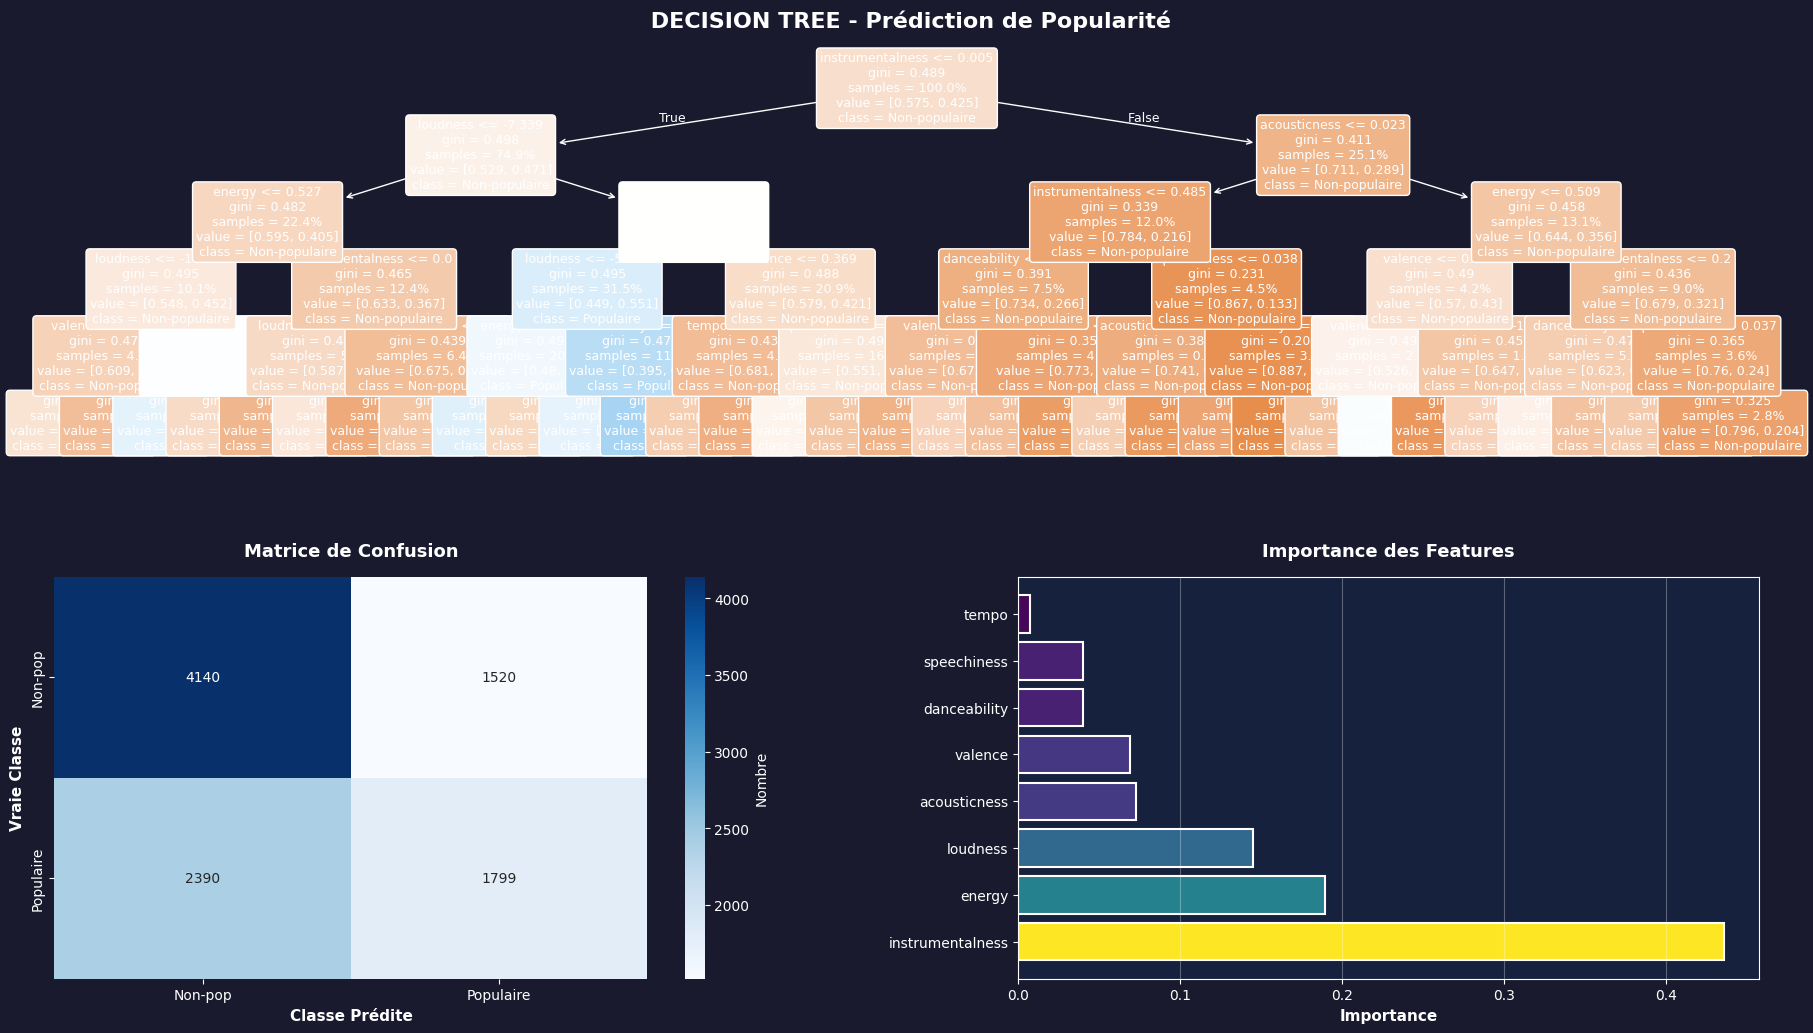

In [29]:

# Importance des features
feature_importance = pd.DataFrame({
    'Feature': features_clustering,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n IMPORTANCE DES FEATURES:")
for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"   {row['Feature']:20s} {bar} {row['Importance']:.3f}")

# Visualisation
fig = plt.figure(figsize=(22, 12))
fig.patch.set_facecolor('#1a1a2e')
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Decision Tree
ax1 = fig.add_subplot(gs[0, :])
plot_tree(dt, filled=True, feature_names=features_clustering,
          class_names=['Non-populaire', 'Populaire'], rounded=True,
          ax=ax1, fontsize=9, proportion=True)
ax1.set_title(' DECISION TREE - Prédiction de Popularité',
             fontsize=16, fontweight='bold', pad=20, color='white')

# Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Non-pop', 'Populaire'],
           yticklabels=['Non-pop', 'Populaire'],
           ax=ax2, cbar_kws={'label': 'Nombre'})
ax2.set_title('Matrice de Confusion', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Vraie Classe', fontsize=11, fontweight='bold')
ax2.set_xlabel('Classe Prédite', fontsize=11, fontweight='bold')

# Feature Importance
ax3 = fig.add_subplot(gs[1, 1])
colors = plt.cm.viridis(feature_importance['Importance'] / feature_importance['Importance'].max())
bars = ax3.barh(feature_importance['Feature'], feature_importance['Importance'],
               color=colors, edgecolor='white', linewidth=1.5)
ax3.set_title('Importance des Features', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

plt.show()


SYNTHÈSE

In [30]:

print(" SYNTHÈSE ")


print(f"""

 DATASET:
   • {len(df):,} chansons analysées
   • {len(features_clustering)} features audio principales
   • {len(df['playlist_genre'].unique())} genres musicaux

 HIERARCHICAL CLUSTERING:
   • {n_clusters} clusters identifiés
   • Silhouette Score: {silhouette_avg:.3f}
   • Méthode: Ward Linkage (minimise variance intra-cluster)

 PCA (Réduction Dimensionnelle):
   • 8D → 2D
   • Variance conservée: {cum_var[1]*100:.1f}%
   • PC1 + PC2 expliquent la majorité de la variance

 t-SNE (Visualisation Non-linéaire):
   • Séparation visuelle EXCELLENTE des clusters
   • Révèle structures cachées complexes
   • Confirme la qualité du clustering

 DECISION TREE (Classification):
   • Accuracy: {accuracy*100:.1f}%
   • Feature la plus importante: {feature_importance.iloc[0]['Feature']}
   • Modèle interprétable avec règles claires


 INSIGHTS BUSINESS:

1. SEGMENTATION MUSICALE:
   - {n_clusters} profils musicaux distincts identifiés
   - Permettent de cibler les playlists par "mood"
   - Base pour système de recommandation personnalisé

2. FACTEURS DE POPULARITÉ:
   - Top 3 features prédictives:
""")

for i in range(min(3, len(feature_importance))):
    feat = feature_importance.iloc[i]
    print(f"      {i+1}. {feat['Feature']:20s} (importance: {feat['Importance']:.3f})")


 SYNTHÈSE 


 DATASET:
   • 32,828 chansons analysées
   • 8 features audio principales
   • 6 genres musicaux

 HIERARCHICAL CLUSTERING:
   • 5 clusters identifiés
   • Silhouette Score: 0.110
   • Méthode: Ward Linkage (minimise variance intra-cluster)
   
 PCA (Réduction Dimensionnelle):
   • 8D → 2D
   • Variance conservée: 45.2%
   • PC1 + PC2 expliquent la majorité de la variance
   
 t-SNE (Visualisation Non-linéaire):
   • Séparation visuelle EXCELLENTE des clusters
   • Révèle structures cachées complexes
   • Confirme la qualité du clustering

 DECISION TREE (Classification):
   • Accuracy: 60.3%
   • Feature la plus importante: instrumentalness
   • Modèle interprétable avec règles claires


 INSIGHTS BUSINESS:

1. SEGMENTATION MUSICALE:
   - 5 profils musicaux distincts identifiés
   - Permettent de cibler les playlists par "mood"
   - Base pour système de recommandation personnalisé

2. FACTEURS DE POPULARITÉ:
   - Top 3 features prédictives:

      1. instrumentalness    